In [1]:
from scripts.GUI import suivi_projet_GUI

In [2]:
app = suivi_projet_GUI() 
app.mainloop()

# DEBUG

In [7]:
import os
import datetime
import numpy as np
import pandas as pd

from scripts.utils import (
    date_to_str,
    get_last_friday,
    get_all_project_names
)

from scripts.aggregate_individual_data import aggregate_individual_data

from scripts.BDD_update_steps import (
    load_data,
    standardize_pipe,
    update_utils_personne,
    update_utils_contrat,
    update_vision_personne,
    update_vision_contrat,
    save_BDD
)

from scripts.GUI import suivi_projet_GUI 
path_dict = suivi_projet_GUI().PATHS
path_dict

{'root_folder': 'P:/Equipe/Suivi de projet staffing/',
 'agg_backup_rpath': 'Données agrégées',
 'link_rpath': 'Données agrégées/Liens/',
 'bdd_file': 'BDD.xlsx',
 'aggregated_data_file': 'Suivi_Projet_Agrégé.xlsx',
 'projects_info_file': 'ILB_Projects.xlsx',
 'backup_bdd_rpath': 'BACKUPS_BDD/'}

In [8]:
aggregated_public_archives, agg_log = aggregate_individual_data(path_dict['root_folder'])
print(agg_log)



Fichiers n'ayant pas pu être lus (potentiellement ouverts pendant l'agrégation) : ~$Suivi_projet_quin_timothee.xlsm


In [7]:
## UPDATING BDD

# LOADING DATA
data = load_data(
    path_dict=path_dict
)

# STANDARDIZE DATA
data, log = standardize_pipe(
    loaded_data=data
)
print('\n'.join(log))

# UPDATE UTILS PERSONNE
utils_personne_new, log = update_utils_personne(
    status_information = data['status_information'], 
    utils_personne_prev = data['bdd_utils_personne']
)
print('\n'.join(log))

# UPDATE UTILS CONTRAT
utils_contrat_new, log = update_utils_contrat(
    budgets_dates_contrats=data['budgets_dates_contrats'], 
    utils_contrat_prev=data['bdd_utils_contrat']
)
print('\n'.join(log))

# UPDATE VISION PERSONNE
vision_personne_new, log = update_vision_personne(
    aggregated_data=data['aggregated_data'], 
    utils_personne=utils_personne_new, 
    utils_contrat=utils_contrat_new, 
    path_dict=path_dict
)
print('\n'.join(log))

# UPDATE VISION CONTRAT
vision_contrat_new = update_vision_contrat(
    vision_personne=vision_personne_new
)

ATTENTION: 1 lignes avec nom de projet erroné (retirées). [nan]
9224 lignes (combinaison personne X date nouvelle) trouvées dans la version précédente de la BDD, mais pas dans les données agrégées, ont été ajoutées.

Aucun changement détecté dans les contrats.
Projets pour lesquels il manque l'information de Type / Sujet :
 - PARC - Soutien Parc
Où modifier ? P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/Analyses_budgetaires_categorisation_V20250910.xlsx


# ANALYSES ANNEXES

In [2]:
from scripts.BDD_update_steps import (
    load_data,
    standardize_pipe,
)

from scripts.utils_analyses_annexes import get_details_about_someone, checking_the_good_labsiens

from scripts.GUI import suivi_projet_GUI 
path_dict = suivi_projet_GUI().PATHS
path_dict

{'root_folder': 'P:/Equipe/Suivi de projet staffing/',
 'agg_backup_rpath': 'Données agrégées',
 'link_rpath': 'Données agrégées/Liens/',
 'bdd_file': 'BDD.xlsx',
 'aggregated_data_file': 'Suivi_Projet_Agrégé.xlsx',
 'projects_info_file': 'ILB_Projects.xlsx',
 'backup_bdd_rpath': 'BACKUPS_BDD/'}

Ces analyses portent sur la base BDD donc il faut les lancer APRES avoir fait la mise à jour de la base avec le code en début de notebook. 

In [3]:
data, log = standardize_pipe(load_data(path_dict))
print('\n\n'.join(log))
      
vision_personne = data['bdd_vision_personne']
vision_contrat = data['bdd_vision_contrat']
utils_personne = data['bdd_utils_personne']
utils_contrat = data['bdd_utils_contrat']

10701 lignes (combinaison personne X date nouvelle) trouvées dans la version précédente de la BDD, mais pas dans les données agrégées, ont été ajoutées.


In [4]:
get_details_about_someone(vision_personne, prenom_nom="juliette.marty", year=2026, month=3)

,h,%
root_name,,
ESG - CAA - Alignement & Empreinte carbone - AVENANT 5,54.0,31.4
ESG - DAM - Impact scoring - AVENANT 0,2.0,1.2
ESG - EDF - Alignement Climatique - AVENANT 2,1.0,0.6
ILB - Congés & Arrêts (hors jours fériés),54.0,31.4
ILB - Participation événement ILB,9.0,5.2
Labs - Participation événement Labs,3.0,1.7
Labs - Point sénior,4.0,2.3
Labs - Prospection - Autres,5.5,3.2
Labs - Prospection - Proposition projet,20.0,11.6


In [5]:
get_details_about_someone(vision_personne, prenom_nom="juliette.marty", year=2026, month=3)["h"].sum()

np.float64(172.0)

Removed: adrien.ferrand, anne.hamon, arnaud.barrat, bertille.tierny, caroline.nguyen, enzo.dalby, felix.thiriat, gabriel.levy, gabriel.plantier, hamada.saleh, iker.tardio, ilias.nahmed, jeremy.dreumont, joao.serta, kelly.bourbon, khalid.arjdal, louis.boulanger, lucas.schnyder, luis.campos, marine.grosmaitre, naja.hammad, nestor.toroman, pauline.aumard, philomene.cholet, sophie.fournier, thomas.renard, yassine.chafai, youssra.bendjebbar


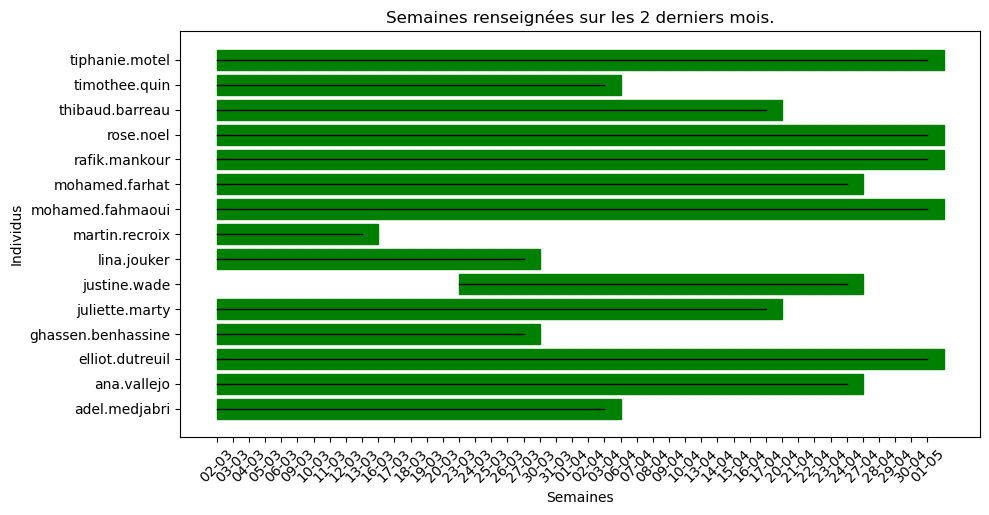

In [6]:
checking_the_good_labsiens(vision_personne, k_months_ago=2)